## Results Pipeline Decision Task 0.2 Scrambled Theta
A notebook that produces all results for the 0.2 scrambled theta condition and the corresponding plots and implements seeding.

In [13]:
# Imports
import sys # for path management
import os

# Add HandcraftApproach directory to path
ha_path = os.path.abspath("/Users/liviastein/STDP_Theta-1/STDP-SR_scripts/Task_Setup/HandcraftApproach")
if ha_path not in sys.path:
    sys.path.insert(0, ha_path)

import importlib
import MazeAgent_HA as MA
importlib.reload(MA)

import copy
import tomplotlib.tomplotlib as tpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import imageio
import random
import pandas as pd
from tqdm.notebook import tqdm

%load_ext autoreload
%autoreload 2

#for plotting in notebook
%matplotlib inline

# define a list of random seeds to loop through for runs of the same experiment
random_seeds = [42]
#random_seeds = [0, 2, 4, 6, 42]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define Agent and Parameters

**General Parameters**
- N = 40 basis features per arm
- peak firing rate = 10Hz
- Theta Frequency = 10Hz
- phase locking parameter kappa = 10

**Scrambling Parameters (DEFAULT)**
- scramble strength = 0.2
- HF jitter = 0.2

**Goal Details**
- goal coordinates = [5.25, 8.0]
- goal raduis = 0.5
- reward = 1.0

Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   initialising theta phases: clean and scrambled
   making the maze walls
   setting goal location and reward
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/550000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
   Adding 'theta scrambled' Condition
   calculating value function based on distance to goal
DONE


(<Figure size 600x800 with 1 Axes>, <Axes: >)

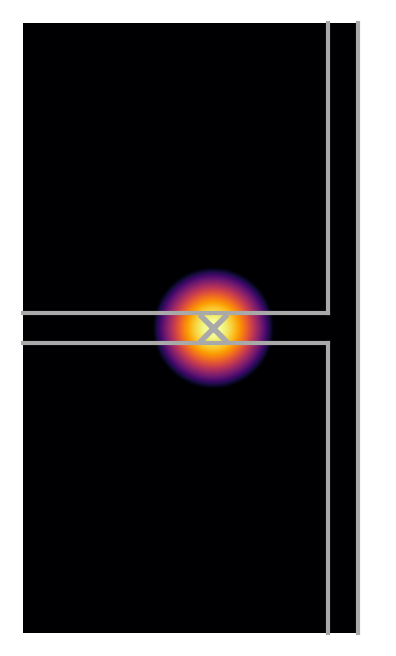

In [14]:
# set up place cells
N = 40
mazeSize = 5.0

# Scale the original TMaze layout to the larger maze
xcen = np.concatenate((
    np.linspace(0.02, 1.00, N) * mazeSize, 
    1.05 * mazeSize * np.ones(N), # 1.05 * mazeSize is the x-coordinate of the rightmost wall of the maze
    1.05 * mazeSize * np.ones(N) # 
))
ycen = np.concatenate((
    np.ones(N) * mazeSize,
    np.linspace(1.03, 2.00, N) * mazeSize, 
    np.linspace(0.97, 0.00, N) * mazeSize
))
centres = np.vstack((xcen, ycen)).T


# set parameters for the MazeAgent class
params = {
           #Maze params 
          'mazeType'            : 'TMaze',  #type of maze, define in getMaze() function
          'stateType'           : 'gaussianThreshold', #feature on which to TD learn (onehot, gaussian, gaussianCS, circles, bump)
          'movementPolicy'      : 'windowsScreensaver',  #movement policy (raudies, random walk, windows screensaver)
          'roomSize'            : mazeSize,          #maze size scaling parameter, metres
          'dt'                  : 0.01,       #simulation time disretisation (defualts to largest )
          'dx'                  : 0.01,       #space discretisation (for plotting, movement is continuous)
          'speedScale'          : 0.16,       #movement speed scale, metres/second
          'rotSpeedScale'       : None,       #rotational speed scale, radians/second
          'initPos'             : None,  #initial position [x0, y0], metres
          'initDir'             : None,      #initial direction, unit vector
          'nCells'              : N,       #how many features to use
          'centres'             : centres,       #array of receptive field positions. Overwrites nCells
          'sigma'               : 1,          #basis cell width scale (irrelevant for onehots)
          'doorsClosed'         : True,       #whether doors are opened or closed in multicompartment maze
          'reorderCells'        : False,       #whether to reorde the cell centres which have been provided
          'firingRateLookUp'    : False,      #use quantised lookup table for firing rates 
          'biasDoorCross'       : False,      #if True, in twoRoom maze door crossings are biased towards
          'biasWallFollow'      : True,       #if True, agent aligns to wall when gets too near.

          #TD params 
          'tau'                 : 4,          #TD decay time, seconds
          'TDdx'                : 0.1,       #rough distance between TD learning updates, metres 
          'alpha'               : 0.01,       #TD learning rate 
          'successorFeatureNorm': 100,        #linear scaling on successor feature definition found to improve learning stability
          'TDreg'               : 0.01,       #L2 regularisation 
          
          #STDP params
          'peakFiringRate'      : 15,          #peak firing rate of a cell (middle of place field,preferred theta phase)
          'tau_STDP_plus'       : 20e-3,      # was 20 pre trace decay time
          'tau_STDP_minus'      : 40e-3,      #was 40 post trace decay time
          'a_STDP'              : -0.4,       # was -0.4, pre-before-post potentiation factor (post-before-pre = 1) 
          'eta'                 : 0.01,       #STDP learning rate
          'baselineFiringRate'  : 0,          #baseline firing rate for cells 
          'use_full_STDP_rule'  : True,      #whether to use full STDP rule     
          'online_mapping'      : 'identity',  #how to map CA3-->CA1 during learning
          'rownorm'             : False,

          #Theta precession params
          'thetaFreq'           : 10,         #theta frequency
          'precessFraction'     : 0.5,        #fraction of 2pi the prefered phase moves through
          'kappa'               : 5,          # von mises spread parameter
          
          #Theta scrambling params (Livi addition)
          'scramble_strength'    : 0.2,        # strength of theta phase scrambling 
          'hf_strength'          : 0.2,        # strength of high frequency jitter added to scrambled theta phase

          # Goal Location
          'goalPos'             : [5.25, 8.0], # 7.5 before. position of goal in metres -> given as array of shape [x, y]
          'goalRadius'          : 0.5,       # radius of goal in metres
          'goalReward'          : 1.0,

}

agent_ST2 = MA.MazeAgent(params)
plotter = MA.Visualiser(agent_ST2)
agent_ST2.toggleDoors(doorsClosed=False)

#plotter.plotMazeStructure() # plot maze structure to check it's correct before starting simulation
plotter.plotReceptiveField(24) # plot receptive field of place cell 5 in the middel of loop
#plotter.plotFeatureCells(centresOnly=True, textlabel=False) # plots centres of the place cells in maze (no heatmap)
#fig, ax = plotter.plotFeatureCells(shufflebeforeplot=False, textlabel=True)
#plotter.plotGoal()

### Make some plots of the Maze, Value Function, Cells
- Value function
- feature cells + maze structure

(<Figure size 600x800 with 1 Axes>, <Axes: >)

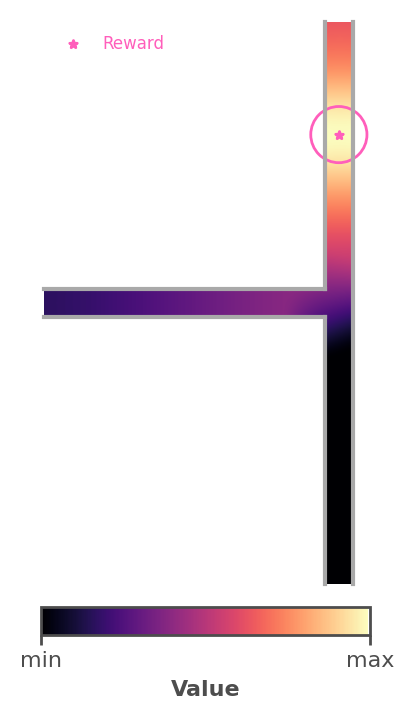

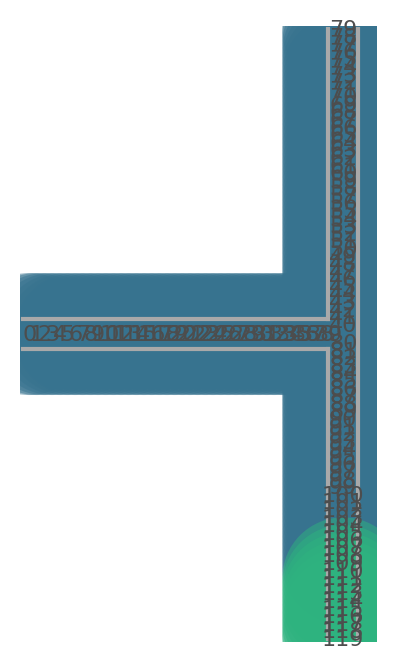

In [9]:
# plot value function
plotter = MA.Visualiser(agent_ST2)

# plot value function
plotter.valueFunctionHeatMap(fig=None, ax=None, smoothing=1, showGoal=True, showCentres=False, save=False)

# plot feature cells
plotter.plotFeatureCells(shufflebeforeplot=False, textlabel=True)

### Pretrain the Agent
- pretrain for 30 minutes  under different conditions
    - TD learning
    - STDP Learning
        - clean theta (10Hz)
        - no theta
        - scrambled theta (0.2; 0.2)
- plot weight matrices for all conditions

**Pretrain Policy**
- Choose left (correct arm) in 90% of cases and right (incorrect) arm in remaining 10% of cases

  0%|          | 0/180000 [00:00<?, ?it/s]

Calculating place and grid cells


(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': "SR matrix 'W' after 30min of STDP learning without theta modulation"}>,
 <Axes: >)

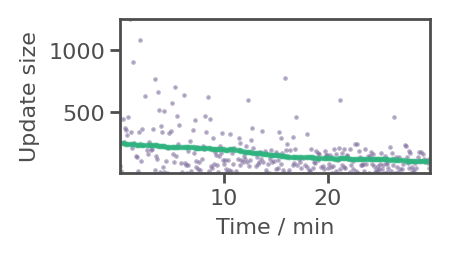

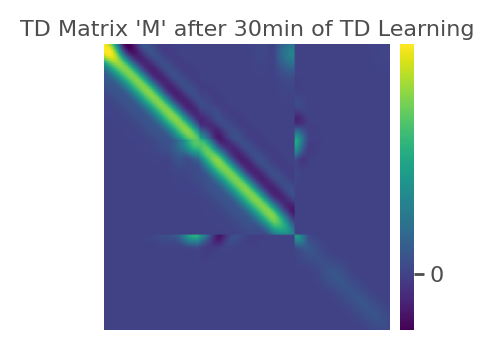

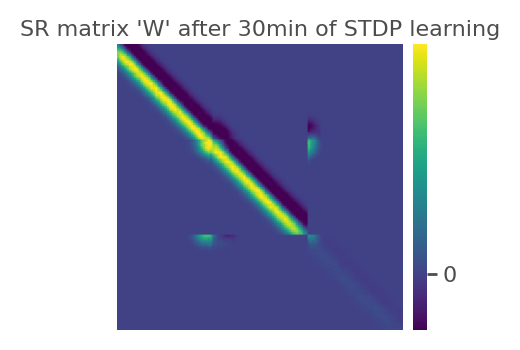

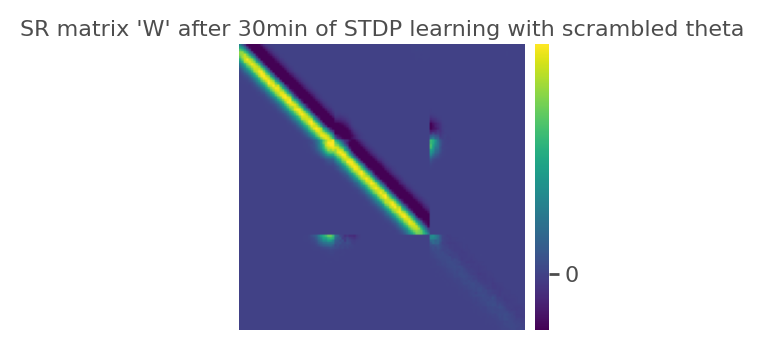

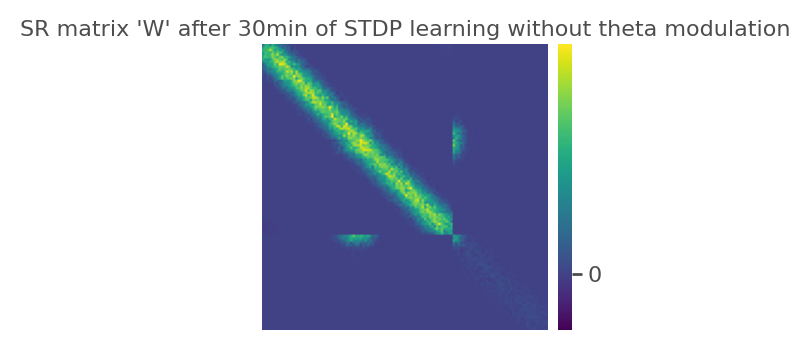

In [15]:
agent_ST2.pos = np.array([0, mazeSize]) # start at the stem center in the scaled T maze
agent_ST2.dir = np.array([1,0]) # start facing right at the start of the stem
agent_ST2.runRat(trainTime=30, STDPLearn=True, TDSRLearn=True, saveEvery=0.5)

# Plot Trajectory for control
plotter = MA.Visualiser(agent_ST2)
#fig, ax = plotter.plotMazeStructure()
#plottimestart, plottimeend = 0, 1
# plotter.plotTrajectory(fig=fig, ax=ax, starttime=plottimestart, endtime=plottimeend)

# Plot SRs fro control
plotter.plotM(whichM="M", colorbar=True, title="TD Matrix 'M' after 30min of TD Learning", save= False) 
plotter.plotM(whichM="W", colorbar=True, title="SR matrix 'W' after 30min of STDP learning", save=False)
# Plot scrambled
plotter.plotM(whichM="W_scrambled", colorbar=True, title="SR matrix 'W' after 30min of STDP learning with scrambled theta", save=False) 
# Plot no_theta
plotter.plotM(whichM="W_notheta", colorbar=True, title="SR matrix 'W' after 30min of STDP learning without theta modulation", save=False)


### Decision Task with Pretrained Agent - 0.2 SCRAMBLED THETA

Running seed 42...
Timeout: 90.0s
dt: 0.01s
Steps: 9000
Expected final elapsed: 90.0s
Epsilon threshold: 89.999999999


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/9500 [00:00<?, ?it/s]

/Users/liviastein/STDP_Theta-1/STDP-SR_scripts/Task_Setup/HandcraftApproach/MazeAgent_HA.py:1022: RuntimeWarning: overflow encountered in exp
  preTrace        *= np.exp(- timeDiff / self.tau_STDP_plus) #traces for all cells decay...
/Users/liviastein/STDP_Theta-1/STDP-SR_scripts/Task_Setup/HandcraftApproach/MazeAgent_HA.py:1023: RuntimeWarning: overflow encountered in exp
  postTrace       *= np.exp(- timeDiff / self.tau_STDP_minus) #traces for all cells decay...
/Users/liviastein/STDP_Theta-1/STDP-SR_scripts/Task_Setup/HandcraftApproach/MazeAgent_HA.py:1025: RuntimeWarning: invalid value encountered in multiply
  W[:,cell]       += self.eta * postTrace #weights from presynaptic neuron should decrease when pre fires (post-before-PRE)
/Users/liviastein/STDP_Theta-1/STDP-SR_scripts/Task_Setup/HandcraftApproach/MazeAgent_HA.py:1028: RuntimeWarning: invalid value encountered in multiply
  W[cell,:]       += self.eta * preTrace #weights to postsynaptic neuron should increase when post fire

Goal reached! Duration: 55.44999999999754. Starting new episode!
Calculating place and grid cells


...

Episode timed out after 95.0 seconds! Starting new episode!
Calculating place and grid cells


  0%|          | 0/9500 [00:00<?, ?it/s]

Goal reached! Duration: 55.289999999949714. Starting new episode!
Calculating place and grid cells


  0%|          | 0/9500 [00:00<?, ?it/s]

Goal reached! Duration: 86.50999999992135. Starting new episode!
Calculating place and grid cells
SUMMARY FOR SEED 42 ONLY!:
Seed 42 Summary:
  Total Episodes: 5
  Reached Goal: 4
  Timeouts: 1
  Wrong Arm Choices: 0
  Percentage Correct: 80.00%
  Average Time to Goal: 60.90249999997156
Overall Summary Across Seeds [42]:
  Total Episodes: 5
  Reached Goal: 4
  Timeouts: 1
  Wrong Arm Choices: 0
  Average Time to Goal: 60.90249999997156
  Percentage Correct: 80.00%


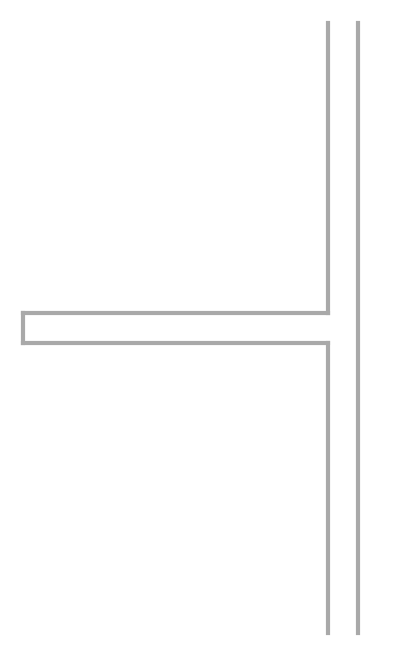

In [17]:
# adapt maze and close off open stem
if agent_ST2.mazeType == "TMaze":
    rs = agent_ST2.roomSize
    corridor_half_width = 0.05 * rs
    agent_ST2.walls['CloseStem'] = np.array([[[0.0, rs-corridor_half_width], [0.0, rs+corridor_half_width]]])
    agent_ST2.mazeState['walls'] = agent_ST2.walls.copy()
    agent_ST2.toggleDoors(doorsClosed=False)
    agent_ST2.discreteStates = agent_ST2.positionArray_to_stateArray(agent_ST2.discreteCoords, stateType= agent_ST2.stateType)
    snapshot = pd.DataFrame({'t': [agent_ST2.t], 'M': [agent_ST2.M.copy()], 'W': [agent_ST2.W.copy()], 'W_notheta':[agent_ST2.W_notheta.copy()], 'W_scrambled':[agent_ST2.W_scrambled.copy()], 'mazeState':[agent_ST2.mazeState]})
    agent_ST2.snapshots = pd.concat([agent_ST2.snapshots, snapshot], ignore_index=True)

# check if maze is changed correctly
plotter = MA.Visualiser(agent_ST2)
plotter.plotMazeStructure()

# run a number of task episodes with pretrained agent (agent_ST2) for each random seed in the list defined earlier, and save results for each seed in a dictionary
results = {}
for seed in random_seeds:
    print(f"Running seed {seed}...")
    np.random.seed(seed); random.seed(seed)

    # save results for seed
    results[seed] = {'episode_logs': [], "episodes": [], "params": params} # to store outcome of each episode for this seed, which we will later use to summarise performance across seeds

    # snapshot agent baseline state 
    base_history_len = len(agent_ST2.history)
    base_snap_len = len(agent_ST2.snapshots)
    baseline_t = agent_ST2.t

    #baseline_theta = getattr(agent_ST2, "thetaPhase", 0.0)
    #baseline_theta_scrambled = getattr(agent_ST2, "thetaPhase_scrambled", 0.0)
    #baseline_spikedata = copy.deepcopy(getattr(agent_ST2, "spikedata", {}))
    #baseline_spikedata_by_condition = copy.deepcopy(getattr(agent_ST2, "spikedata_by_condition", {}))
    #baseline_decoded = copy.deepcopy(getattr(agent_ST2, "decoded_dir_history", []))
    baseline_runID = agent_ST2.runID

    M_before = agent_ST2.M.copy()
    W_before = agent_ST2.W.copy()
    W_notheta_before = agent_ST2.W_notheta.copy()
    W_scrambled_before = agent_ST2.W_scrambled.copy()

    # reset episode-local state (clean start, keep weights)
    agent_ST2.pos = np.array([0.2, mazeSize])            # or [0, mazeSize] per your convention
    agent_ST2.dir = np.array([1.0, 0.0])
    agent_ST2.speed = agent_ST2.speedScale
    agent_ST2.t = 0.0
    agent_ST2.thetaPhase = 0.0
    agent_ST2.thetaPhase_scrambled = 0.0
    agent_ST2.thetaPhase_scrambled_history = []
    agent_ST2.thetaPhase_scrambled_time_history = []

    agent_ST2.spikedata = {'CA3': {'times': [], 'ids': []}, 'CA1': {'times': [], 'ids': []}}
    agent_ST2.spikedata_by_condition = {
        'theta': {'CA1': {'times': [], 'ids': []}, 'CA3': {'times': [], 'ids': []}},
        'notheta': {'CA1': {'times': [], 'ids': []}, 'CA3': {'times': [], 'ids': []}},
        'scrambled': {'CA1': {'times': [], 'ids': []}, 'CA3': {'times': [], 'ids': []}}
    }
    agent_ST2.decoded_dir_history = []
    agent_ST2.reachedGoal = False
    agent_ST2.goalReachedTime = 0.0
    agent_ST2.lastTurnUpdate = -1
    agent_ST2.randomTurnSpeed = 0
    agent_ST2.doorPassage = False
    agent_ST2.doorPassageTime = 0.0

    # Diagnostic: check timeout condition behavior
    timeout_test = 90.0
    dt_test = agent_ST2.dt
    steps_test = int(timeout_test / dt_test)
    print(f"Timeout: {timeout_test}s")
    print(f"dt: {dt_test}s")
    print(f"Steps: {steps_test}")
    print(f"Expected final elapsed: {steps_test * dt_test}s")
    print(f"Epsilon threshold: {timeout_test - 1e-9}")


    # run decision task episodes
    episodes = 5
    for ep in tqdm(range(episodes)):
        history_start = len(agent_ST2.history)
        snapshot_start = len(agent_ST2.snapshots)
        t_start = agent_ST2.t
        runid_start = agent_ST2.runID

        outcome = agent_ST2.TaskEpisode(saveEvery=0.5, 
                                        TDSRLearn=True, 
                                        STDPLearn=True, 
                                        condition = 'scrambled', 
                                        phase_threshold = 1.3*np.pi, 
                                        t_window =None,
                                        updateSTDPWeights = False,
                                        maxTurnAngle = True,
                                        maxAngle = 50.0,
                                        timeout = 95.0)
        # store outcome of episode
        history_end = len(agent_ST2.history)
        snapshot_end = len(agent_ST2.snapshots)
        t_end = agent_ST2.t
        runid_end = agent_ST2.runID

        assert runid_end == runid_start + 1, (
              f"runID mismatch at seed={seed}, ep={ep}: "
              f"start={runid_start}, end={runid_end}"
        )

        # metadata row for this episode
        metadata = {
            'seed': seed,
            'episode': ep,
            'runID_start': runid_start,
            'runID_end': runid_end,
            't_start': t_start,
            't_end': t_end,
            "duration": t_end - t_start,
            "history_start": history_start,
            "history_end": history_end,
            "snapshot_start": snapshot_start,
            "snapshot_end": snapshot_end,
            "outcome": outcome
        }
        results[seed]['episode_logs'].append(metadata)

        # payload data for this episode
        payload = {"history": agent_ST2.history.iloc[history_start:history_end].reset_index(drop=True),
                     "snapshots": agent_ST2.snapshots.iloc[snapshot_start:snapshot_end].reset_index(drop=True),
                     "spikedata": copy.deepcopy(agent_ST2.spikedata),
                     "spikedata_by_condition": copy.deepcopy(agent_ST2.spikedata_by_condition),
                     "final_weights": {
                          'M': agent_ST2.M.copy(),
                          'W': agent_ST2.W.copy(),
                          'W_notheta': agent_ST2.W_notheta.copy(),
                          'W_scrambled': agent_ST2.W_scrambled.copy()
                     }
          }       
        results[seed]['episodes'].append(payload)

    # save final outcome/weights if desired
    results[seed]["final_weights_pre_restore"] = {
        "M": agent_ST2.M.copy(), "W": agent_ST2.W.copy(),
        "W_notheta": agent_ST2.W_notheta.copy(), "W_scrambled": agent_ST2.W_scrambled.copy()
    }

    # 6) restore agent to baseline (clean reset) so next seed starts from same pretrained state
    agent_ST2.M = M_before
    agent_ST2.W = W_before
    agent_ST2.W_notheta = W_notheta_before
    agent_ST2.W_scrambled = W_scrambled_before
    agent_ST2.history = agent_ST2.history.iloc[:base_history_len].reset_index(drop=True)
    agent_ST2.snapshots = agent_ST2.snapshots.iloc[:base_snap_len].reset_index(drop=True)
    agent_ST2.t = baseline_t
    agent_ST2.runID = baseline_runID

# restore original maze -> open stem again
if 'CloseStem' in getattr(agent_ST2, 'walls', {}):
                del agent_ST2.walls['CloseStem'] # remove wall closing stem after decision task is done, so agent can explore whole maze again
                agent_ST2.mazeState['walls'] = agent_ST2.walls.copy()
                agent_ST2.toggleDoors(doorsClosed = False) # make sure right arm is open again
                agent_ST2.discreteStates = agent_ST2.positionArray_to_stateArray(agent_ST2.discreteCoords, stateType=agent_ST2.stateType) # recalculate discrete states to account for removed wall 
            
# summarise performance results per seed episodes and across seeds: i.e. get reward count, total reward, number of timeouts, number of wrong arm choices, and average time to reach goal.
summary = []
for seed, data in results.items():
    episode_logs = data['episode_logs']
    episodes = data['episodes']

    # summarise for one seed
    outcome_rows = []
    for log in episode_logs:
        outcome = log['outcome']
        if outcome['reward_count'] > 0:
            label = 'reached_goal'
        elif outcome['wrong_arm_count'] > 0:
            label = 'wrong_arm'
        elif outcome['timeout_count'] > 0:
            label = 'timeout'
        else:
            label = 'unknown'
        outcome_rows.append({'label': label, 'duration': log['duration']})

    outcome_df = pd.DataFrame(outcome_rows)
    seed_summary = {
        'seed': seed,
        'total_episodes': len(episode_logs),
        'reached_goal': int((outcome_df['label'] == 'reached_goal').sum()),
        'timeouts': int((outcome_df['label'] == 'timeout').sum()),
        'wrong_arm': int((outcome_df['label'] == 'wrong_arm').sum()),
        'percentage_correct': float((outcome_df['label'] == 'reached_goal').sum()) / len(outcome_df) if len(outcome_df) > 0 else np.nan,
        'average_time_to_goal': float(outcome_df.loc[outcome_df['label'] == 'reached_goal', 'duration'].mean()) if (outcome_df['label'] == 'reached_goal').any() else np.nan
    }
    summary.append(seed_summary)
    # print summary for this seed
    print(f"SUMMARY FOR SEED {seed} ONLY!:")
    print(f"Seed {seed} Summary:")
    print(f"  Total Episodes: {seed_summary['total_episodes']}")
    print(f"  Reached Goal: {seed_summary['reached_goal']}")
    print(f"  Timeouts: {seed_summary['timeouts']}")
    print(f"  Wrong Arm Choices: {seed_summary['wrong_arm']}")
    print(f"  Percentage Correct: {seed_summary['percentage_correct']:.2%}")
    print(f"  Average Time to Goal: {seed_summary['average_time_to_goal']}")
    print("========================================")

# summary across seeds
total_episodes = sum(s['total_episodes'] for s in summary)
total_reached_goal = sum(s['reached_goal'] for s in summary)
total_timeouts = sum(s['timeouts'] for s in summary)
total_wrong_arm = sum(s['wrong_arm'] for s in summary)
goal_times = [s['average_time_to_goal'] for s in summary if not np.isnan(s['average_time_to_goal'])]
average_time_to_goal = float(np.mean(goal_times)) if len(goal_times) > 0 else np.nan
print(f"Overall Summary Across Seeds {random_seeds}:")
print(f"  Total Episodes: {total_episodes}")
print(f"  Reached Goal: {total_reached_goal}")
print(f"  Timeouts: {total_timeouts}")
print(f"  Wrong Arm Choices: {total_wrong_arm}")
print(f"  Average Time to Goal: {average_time_to_goal}")
print(f"  Percentage Correct: {total_reached_goal / total_episodes:.2%}" if total_episodes > 0 else np.nan)
print("========================================")


### Performance Plots

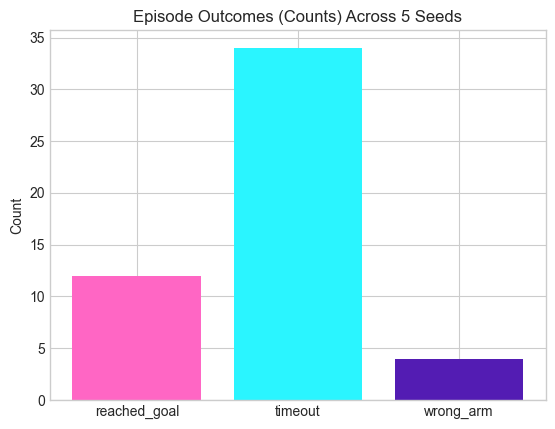

In [26]:
plt.close('all')
plt.rcdefaults()
# bar plot with outcomes across seeds as counts
# use specific style for plot
plt.style.use('seaborn-v0_8-whitegrid')
# define own color palette with colour keys
Livi_palette = ['#ff66c4', '#2AF5FF', '#531CB3']

summary_df = pd.DataFrame(summary)
labels = ['reached_goal', 'timeout', 'wrong_arm']
counts = [
    int(summary_df['reached_goal'].sum()),
    int(summary_df['timeouts'].sum()),
    int(summary_df['wrong_arm'].sum())
 ]
x = np.arange(len(labels))

fig, ax = plt.subplots()
bars = ax.bar(x, counts, color= Livi_palette)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Count')
ax.set_title('Episode Outcomes (Counts) Across 5 Seeds')

plt.show()

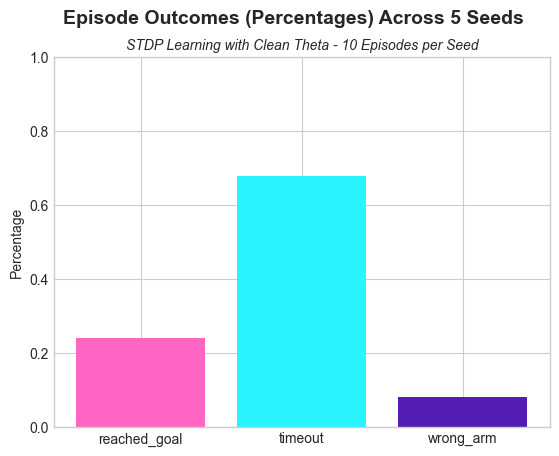

In [30]:
plt.close('all')
plt.rcdefaults()
# bar plot with outcomes across seeds as percentages: e.g. timout/total episodes etc
# use specific style for plot
plt.style.use('seaborn-v0_8-whitegrid')
# define own color palette with colour keys
Livi_palette = ['#ff66c4', '#2AF5FF', '#531CB3']

#summary_df = pd.DataFrame(summary)
labels = ['reached_goal', 'timeout', 'wrong_arm']
total_episodes = sum(s['total_episodes'] for s in summary)
reached = sum(s['reached_goal'] for s in summary)
timeouts = sum(s['timeouts'] for s in summary)
wrong_arm = sum(s['wrong_arm'] for s in summary)
percentages = [reached/total_episodes, timeouts/total_episodes, wrong_arm/total_episodes] if total_episodes>0 else [np.nan]*3

#total_episodes = summary_df['total_episodes'].sum()
#percentages = [
    #float(summary_df['reached_goal'].sum()) / total_episodes if total_episodes > 0 else np.nan,
    #float(summary_df['timeouts'].sum()) / total_episodes if total_episodes > 0 else np.nan,
    #float(summary_df['wrong_arm'].sum()) / total_episodes if total_episodes > 0 else np.nan
#]
x = np.arange(len(labels))
fig, ax = plt.subplots()
bars = ax.bar(x, percentages, color= Livi_palette)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Percentage')
# set limit for y axis to 0-100%
ax.set_ylim(0, 1)
plt.suptitle('Episode Outcomes (Percentages) Across 5 Seeds', fontsize=14, fontweight='bold')
# add subtitle with theta condition and number of episodes in italics
ax.set_title(f"STDP Learning with Clean Theta - {10} Episodes per Seed", fontsize=10, fontstyle='italic', loc='center')

plt.show()

per-seed successful counts: {0: 4, 2: 1, 4: 1, 6: 3, 42: 3}
sum of per-seed successful counts: 12
summary total_reached_goal (from seed summaries): 12


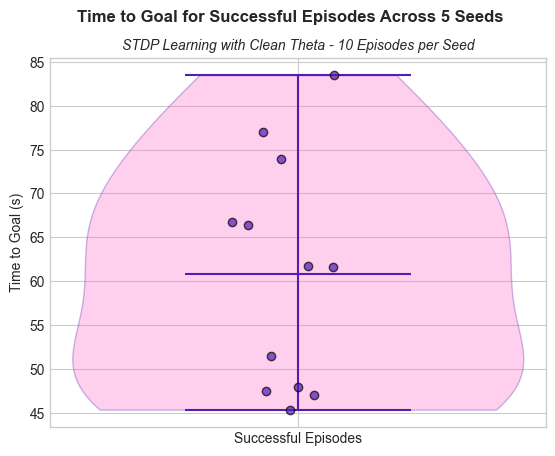

In [28]:
plt.close('all')
plt.rcdefaults()
# create violin plot of time to goal for successful episodes across seeds
plt.style.use('seaborn-v0_8-whitegrid')
# define own color palette with colour keys
Livi_palette = ['#ff66c4', '#2AF5FF', '#531CB3']
total_episodes = sum(s['total_episodes'] for s in summary)
# debug: per-seed successful counts (from `results`)
success_counts = {
    seed: sum(1 for log in data['episode_logs'] if log.get('outcome', {}).get('reward_count', 0) > 0)
    for seed, data in results.items()
}
print('per-seed successful counts:', success_counts)
print('sum of per-seed successful counts:', sum(success_counts.values()))
print('summary total_reached_goal (from seed summaries):', sum(s['reached_goal'] for s in summary))

# collect per-episode durations for successful episodes (reward_count > 0)
successful_times = [
    log['duration']
    for seed, data in results.items()
    for log in data['episode_logs']
    if log.get('outcome', {}).get('reward_count', 0) > 0
]

# convert to numpy array for plotting (optional)
successful_times = np.array(successful_times)

fig, ax = plt.subplots()
ax.violinplot(successful_times, showmeans=True, showmedians=False, showextrema=True)
# set face colour and edge colour of the violin plot
for body in ax.collections:
    try:
        body.set_facecolor(Livi_palette[0])
        body.set_edgecolor(Livi_palette[2])
    except Exception:
        pass

# scatter actual data points from episodes on top of violin plot and spread them a bit horizontally
x = np.random.normal(1, 0.04, size=len(successful_times))  # spread around x=1 with small random noise
ax.scatter(x, successful_times, color=Livi_palette[2], alpha=0.7, edgecolor='k', zorder=2)

# set y-limits sensibly
if len(successful_times) > 0:
    ymin = max(0, successful_times.min() - 2)
    ymax = successful_times.max() + 2
    ax.set_ylim(ymin, ymax)
else:
    ax.set_ylim(0, 1)

ax.set_xticks([1])
ax.set_xticklabels(['Successful Episodes'])
ax.set_ylabel('Time to Goal (s)')
plt.suptitle('Time to Goal for Successful Episodes Across 5 Seeds', fontsize=12, fontweight='bold')
ax.set_title(f"STDP Learning with Clean Theta - {10} Episodes per Seed", fontsize=10, fontstyle='italic', loc='center')
plt.show()

### Summarise the Results in Tables and Export

In [29]:
from pathlib import Path

theta_condition = "ScrTheta_0.2"  # change this in each notebook
out_dir = Path("/Users/liviastein/STDP_Theta-1/ResultPipelines/summary_tables")
out_dir.mkdir(parents=True, exist_ok=True)

rows = []
for seed, data in results.items():
    for log in data["episode_logs"]:
        outcome = log.get("outcome", {})
        if outcome.get("reward_count", 0) > 0:
            label = "reached_goal"
        elif outcome.get("wrong_arm_count", 0) > 0:
            label = "wrong_arm"
        elif outcome.get("timeout_count", 0) > 0:
            label = "timeout"
        else:
            label = "unknown"

        rows.append({
            "theta_condition": theta_condition,
            "seed": seed,
            "episode": log.get("episode"),
            "label": label,
            "duration": log.get("duration", np.nan),
            "reward_count": outcome.get("reward_count", 0),
            "wrong_arm_count": outcome.get("wrong_arm_count", 0),
            "timeout_count": outcome.get("timeout_count", 0),
        })

episode_table = pd.DataFrame(rows)

seed_summary_table = (
    episode_table.groupby(["theta_condition", "seed"], as_index=False)
    .agg(
        total_episodes=("episode", "count"),
        reached_goal=("label", lambda s: int((s == "reached_goal").sum())),
        wrong_arm=("label", lambda s: int((s == "wrong_arm").sum())),
        timeouts=("label", lambda s: int((s == "timeout").sum())),
        percentage_correct=("label", lambda s: float((s == "reached_goal").sum()) / len(s) if len(s) > 0 else np.nan),
        average_time_to_goal=("duration", lambda s: float(s[episode_table.loc[s.index, "label"] == "reached_goal"].mean())
                              if (episode_table.loc[s.index, "label"] == "reached_goal").any() else np.nan),
    )
)

episode_table.to_csv(out_dir / f"{theta_condition}_episode_table.csv", index=False)
seed_summary_table.to_csv(out_dir / f"{theta_condition}_seed_summary_table.csv", index=False)

print(episode_table.head())
print("===============================")
print(seed_summary_table)

  theta_condition  seed  episode         label  duration  reward_count  \
0    ScrTheta_0.2     0        0  reached_goal     61.64             1   
1    ScrTheta_0.2     0        1       timeout     85.00             0   
2    ScrTheta_0.2     0        2       timeout     85.01             0   
3    ScrTheta_0.2     0        3     wrong_arm     58.14             0   
4    ScrTheta_0.2     0        4  reached_goal     45.35             1   

   wrong_arm_count  timeout_count  
0                0              0  
1                0              1  
2                0              1  
3                1              0  
4                0              0  
  theta_condition  seed  total_episodes  reached_goal  wrong_arm  timeouts  \
0    ScrTheta_0.2     0              10             4          1         5   
1    ScrTheta_0.2     2              10             1          2         7   
2    ScrTheta_0.2     4              10             1          0         9   
3    ScrTheta_0.2     6    

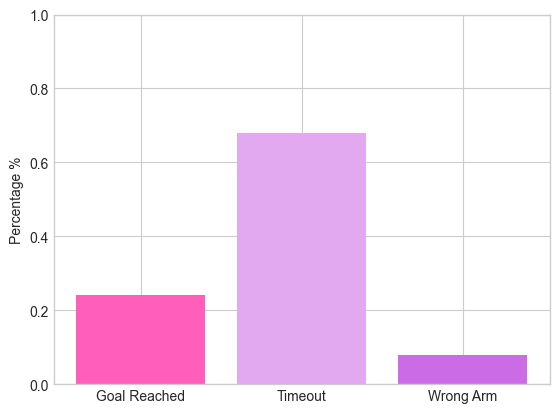

In [31]:
# bar plot with outcomes across seeds as percentages: e.g. timout/total episodes etc
# use specific style for plot
plt.style.use('seaborn-v0_8-whitegrid')
# define own color palette with colour keys
#Livi_palette1 = ['#ff66c4', '#2AF5FF', '#531CB3']
Livi_palette = {
    "türkis": '#66dfd8',
    "lBlue": '#1097d3',
    "dViolet": '#5e17eb',
    "lpurple": '#8c52ff',
    "altRosa": '#cb6ce6',
    "lRosa": '#e2a9f1',
    "pink": '#ff5ebb'
}

#summary_df = pd.DataFrame(summary)
labels = ['Goal Reached', 'Timeout', 'Wrong Arm']
total_episodes = sum(s['total_episodes'] for s in summary)
reached = sum(s['reached_goal'] for s in summary)
timeouts = sum(s['timeouts'] for s in summary)
wrong_arm = sum(s['wrong_arm'] for s in summary)
percentages = [reached/total_episodes, timeouts/total_episodes, wrong_arm/total_episodes] if total_episodes>0 else [np.nan]*3

#total_episodes = summary_df['total_episodes'].sum()
#percentages = [
    #float(summary_df['reached_goal'].sum()) / total_episodes if total_episodes > 0 else np.nan,
    #float(summary_df['timeouts'].sum()) / total_episodes if total_episodes > 0 else np.nan,
    #float(summary_df['wrong_arm'].sum()) / total_episodes if total_episodes > 0 else np.nan
#]
x = np.arange(len(labels))
fig, ax = plt.subplots()
bars = ax.bar(x, percentages, color= [Livi_palette['pink'], Livi_palette['lRosa'], Livi_palette['altRosa']])
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Percentage %')
# set limit for y axis to 0-100%
ax.set_ylim(0, 1)
#plt.suptitle('Episode Outcomes (Percentages) Across 50 Seeds', fontsize=14, fontweight='bold')
# add subtitle with theta condition and number of episodes in italics
#ax.set_title(f"STDP Learning with Clean Theta - {total_episodes} Episodes per Seed", fontsize=10, fontstyle='italic', loc='center')

plt.show()

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def _get_pos(a, t_hist):
    """Extract x, y position history from agent at each timepoint, handling (x,y) tuple columns."""
    #if hasattr(a, 'pos_history'):
        #return np.asarray(a.pos_history, dtype=float)[:len(t_hist)]
    
    # pos column contains (x, y) tuples/arrays per row — stack them into a 2D array
    pos_series = a.history['pos'].iloc[:len(t_hist)]
    return np.stack(pos_series.values).astype(float)  # shape (n_timepoints, 2) which means [x, y] per timepoint

def _get_positions(a, t_hist):
    """Extract x, y position history aligned to t_hist."""
    if hasattr(a, 'pos_history'):
        pos = np.asarray(a.pos_history, dtype=float)
    elif 'x' in a.history.columns:
        pos = a.history[['x', 'y']].to_numpy(dtype=float)
    else:
        raise AttributeError("Cannot find position history on agent.")
    return pos[:len(t_hist)]   # align length to t_hist

def _get_t_history(a):
    """Extract time history from the agent, i.e. the timepoints at which positions and spikes were recorded.
    Returns a 1D numpy array of timepoints (float)
    """
    if hasattr(a, "t_history"):
        return np.asarray(a.t_history, dtype=float).reshape(-1)
    return a.history["t"].to_numpy(dtype=float)

def _get_ca1(a, cond_key):
    """Extract CA1 spike data for a given condition key (e.g. 'theta', 'notheta', 'scrambled') from the agent's spikedata_by_condition.
    Returns the CA1 spike data structure for that condition.
    """
    d = a.spikedata_by_condition
    if cond_key in d:
        return d[cond_key]["CA1"]
    if cond_key == "scrambled_theta" and "scrambled" in d:
        return d["scrambled"]["CA1"]
    raise KeyError(f"Condition '{cond_key}' not found in spikedata_by_condition.")

def _get_spikes(ca1, cell_id):
    """Extract spike times for a given cell_id from the CA1 spike data structure, which may be in one of several formats.
    Returns a 1D numpy array of spike times for the specified cell_id.
    """
    # expected format: CA1[cell_id]['times']
    if isinstance(ca1, (list, tuple)):
        return np.asarray(ca1[cell_id]["times"], dtype=float).reshape(-1) # return spike times for this cell

    # alternate format: {'times':..., 'ids':...}
    if isinstance(ca1, dict) and ("times" in ca1) and ("ids" in ca1):
        st = np.asarray(ca1["times"], dtype=float).reshape(-1) # spike times
        sid = np.asarray(ca1["ids"], dtype=int).reshape(-1) # corresponding cell ids for each spike time
        return st[sid == cell_id] # return spike times for this cell by masking with cell_id

    # dict keyed by cell_id
    if isinstance(ca1, dict) and (cell_id in ca1):
        return np.asarray(ca1[cell_id]["times"], dtype=float).reshape(-1) # return spike times for this cell

    raise TypeError("Unsupported CA1 spike format.")

cond_key  = 'theta'            # or 'scrambled_theta'
neuron_id = 39
agent      = agent_ST2

t_hist    = _get_t_history(agent)
positions = _get_pos(agent, t_hist)
ca1       = _get_ca1(agent, cond_key)
spikes    = _get_spikes(ca1, neuron_id)   # 1D array of spike times

def plot_place_field(fig, ax, spike_times, positions, times, neuron_id,
                     bin_size=2.5, sigma=1.5):
    """
    Parameters
    ----------
    fig, ax       : from plotMazeStructure()
    spike_times   : dict {neuron_id: array of spike times}  OR  2D array (n_spikes, 2) with [neuron_id, time]
    positions     : 2D array (n_timepoints, 2) with [x, y] agent positions
    times         : 1D array of timepoints matching positions
    neuron_id     : which neuron to plot (e.g. 5)
    bin_size      : spatial bin size in whatever units your maze uses
    sigma         : gaussian smoothing (in bins); increase for smoother field
    """

    # ── 1. Extract spike times for the chosen neuron ──────────────────────────
    if isinstance(spike_times, dict):
        neuron_spikes = np.asarray(spike_times[neuron_id])
    else:
        mask = spike_times[:, 0] == neuron_id
        neuron_spikes = spike_times[mask, 1]

    # ── 2. Find agent position at each spike time ─────────────────────────────
    spike_positions = np.array([
        positions[np.argmin(np.abs(times - t))]
        for t in neuron_spikes
    ])

    # ── 3. Define spatial bins from maze extent ───────────────────────────────
    x_min, x_max = positions[:, 0].min(), positions[:, 0].max()
    y_min, y_max = positions[:, 1].min(), positions[:, 1].max()

    x_bins = np.arange(x_min, x_max + bin_size, bin_size)
    y_bins = np.arange(y_min, y_max + bin_size, bin_size)

    # ── 4. Occupancy map (time spent in each bin) ─────────────────────────────
    occupancy, _, _ = np.histogram2d(
        positions[:, 0], positions[:, 1],
        bins=[x_bins, y_bins]
    )
    dt = np.mean(np.diff(times))          # seconds per sample
    occupancy_sec = occupancy * dt        # convert counts → seconds

    # ── 5. Spike count map ────────────────────────────────────────────────────
    spike_map, _, _ = np.histogram2d(
        spike_positions[:, 0], spike_positions[:, 1],
        bins=[x_bins, y_bins]
    )

    # ── 6. Firing rate map = spikes / occupancy; mask unvisited bins ──────────
    min_occupancy = 0.1                   # seconds; ignore barely-visited bins
    rate_map = np.full(spike_map.shape, np.nan)
    visited = occupancy_sec > min_occupancy
    rate_map[visited] = spike_map[visited] / occupancy_sec[visited]

    # ── 7. Gaussian smooth (ignore NaNs) ─────────────────────────────────────
    filled = np.where(np.isnan(rate_map), 0, rate_map)
    smoothed = gaussian_filter(filled, sigma=sigma)
    smoothed[~visited] = np.nan           # reapply NaN mask after smoothing

    # ── 8. Plot on existing maze figure ───────────────────────────────────────
    # Fix: use pcolormesh instead of imshow — no transpose needed, no extent ambiguity
    x_centers = (x_bins[:-1] + x_bins[1:]) / 2
    y_centers = (y_bins[:-1] + y_bins[1:]) / 2

    im = ax.pcolormesh(
        x_centers, y_centers,
        smoothed.T,          # pcolormesh also expects (y, x) so .T is correct here
        cmap='hot',
        alpha=0.75,
        zorder=2
    )
    #extent = [x_min, x_max, y_min, y_max]
    #im = ax.imshow(
        #smoothed.T,                       # transpose: imshow expects (y, x)
        #origin='lower',
        #extent=extent,
        #cmap='hot',
        #alpha=0.75,                       # lets maze structure show through
        #aspect='auto',
        #interpolation='bilinear'
    #)

    # Overlay individual spike locations as dots
    #ax.scatter(spike_positions[:, 0], spike_positions[:, 1],
               #s=4, c='#f55ebb', alpha=0.4, zorder=3)

    cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('Firing rate (Hz)', fontsize=8)

    ax.set_title(f'Neuron {neuron_id} — place field\n'
                 f'({len(neuron_spikes)} spikes)', fontsize=9)

    return smoothed, x_bins, y_bins

In [76]:
cond_key  = 'theta'
neuron_id = 5



t_hist    = _get_t_history(agent)
positions = _get_pos(agent, t_hist)
ca1       = _get_ca1(agent, cond_key)
spikes    = _get_spikes(ca1, neuron_id)

print(f"t_hist:    {t_hist.shape},    range [{t_hist.min():.2f}, {t_hist.max():.2f}] s")
print(f"positions: {positions.shape}, range x={positions[:,0].min():.2f}–{positions[:,0].max():.2f}, y={positions[:,1].min():.2f}–{positions[:,1].max():.2f}")
print(f"spikes:    {spikes.shape},    range [{spikes.min():.2f}, {spikes.max():.2f}] s")
print(t_hist[:5]) # print first 5 timepoints
print(positions[:5]) # print first 5 positions
print(spikes[:10]) # print first 5 spike times

t_hist:    (179999,),    range [0.01, 1799.99] s
positions: (179999, 2), range x=0.00–5.25, y=0.00–10.00
spikes:    (725,),    range [0.09, 255.94] s
[0.01 0.02 0.03 0.04 0.05]
[[1.6e-03 5.0e+00]
 [3.2e-03 5.0e+00]
 [4.8e-03 5.0e+00]
 [6.4e-03 5.0e+00]
 [8.0e-03 5.0e+00]]
[0.08700866 0.28618946 0.36671526 0.57640473 0.67806484 0.6833117
 0.78428412 0.87971442 0.88440377 0.960356  ]


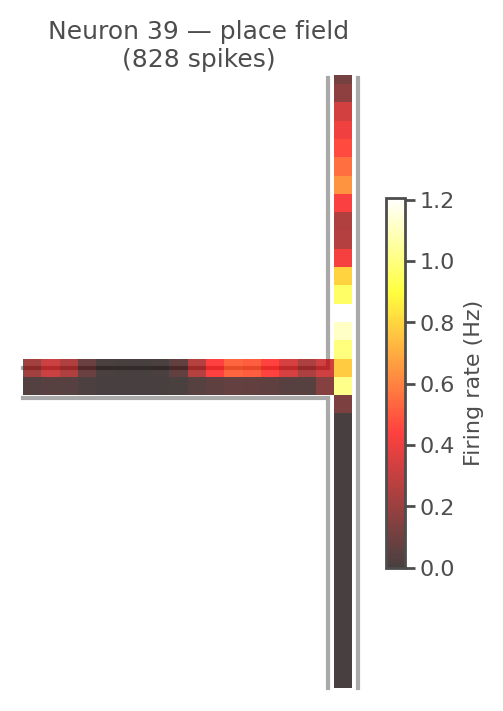

In [158]:
fig, ax = plotter.plotMazeStructure()

rate_map, x_bins, y_bins = plot_place_field(
    fig, ax,
    spike_times = {neuron_id: spikes},
    positions   = positions,
    times       = t_hist,
    neuron_id   = neuron_id,
    bin_size    = 0.3,
    sigma       = 0.5
)

plt.show()

In [79]:
print(f"t_hist range:  {t_hist.min():.4f} – {t_hist.max():.4f}")
print(f"spikes range:  {spikes.min():.4f} – {spikes.max():.4f}")
# both should be in seconds and overlapping

t_hist range:  0.0100 – 1799.9900
spikes range:  0.0870 – 255.9413


In [80]:
dt = np.mean(np.diff(t_hist))
print(f"dt (timestep): {dt*1000:.3f} ms")   # e.g. 5ms → fine

# check actual matching error for all spikes
errors = np.array([np.min(np.abs(t_hist - t)) for t in spikes])
print(f"Max matching error: {errors.max()*1000:.3f} ms")
print(f"Mean matching error: {errors.mean()*1000:.3f} ms")

dt (timestep): 10.000 ms
Max matching error: 4.982 ms
Mean matching error: 2.504 ms


In [81]:
for t in spikes[:5]:
    idx = np.argmin(np.abs(t_hist - t))
    print(f"spike t={t:.4f}s → closest t_hist={t_hist[idx]:.4f}s (err={abs(t_hist[idx]-t)*1000:.2f}ms) → pos={positions[idx]}")

spike t=0.0870s → closest t_hist=0.0900s (err=2.99ms) → pos=[0.0144 5.    ]
spike t=0.2862s → closest t_hist=0.2900s (err=3.81ms) → pos=[0.0464 5.    ]
spike t=0.3667s → closest t_hist=0.3700s (err=3.28ms) → pos=[0.0592 5.    ]
spike t=0.5764s → closest t_hist=0.5800s (err=3.60ms) → pos=[0.0928 5.    ]
spike t=0.6781s → closest t_hist=0.6800s (err=1.94ms) → pos=[0.1088 5.    ]


In [82]:
# Compare forward vs backward matching
for t in spikes[:5]:
    idx = np.argmin(np.abs(t_hist - t))
    idx_back = max(0, idx - 1)   # one step back
    print(f"spike t={t:.4f}s")
    print(f"  matched pos:       {positions[idx]}")
    print(f"  one step back pos: {positions[idx_back]}")

spike t=0.0870s
  matched pos:       [0.0144 5.    ]
  one step back pos: [0.0128 5.    ]
spike t=0.2862s
  matched pos:       [0.0464 5.    ]
  one step back pos: [0.0448 5.    ]
spike t=0.3667s
  matched pos:       [0.0592 5.    ]
  one step back pos: [0.0576 5.    ]
spike t=0.5764s
  matched pos:       [0.0928 5.    ]
  one step back pos: [0.0912 5.    ]
spike t=0.6781s
  matched pos:       [0.1088 5.    ]
  one step back pos: [0.1072 5.    ]


In [83]:
# Do spike times exceed one episode duration?
episode_dur = t_hist.max() / 10
print(f"Episode duration: {episode_dur:.1f}s")
print(f"Spikes beyond ep1: {np.sum(spikes > episode_dur)}")

# Does t_hist ever reset (drop backwards)?
resets = np.where(np.diff(t_hist) < 0)[0]
print(f"t_hist resets at indices: {resets}")

Episode duration: 180.0s
Spikes beyond ep1: 171
t_hist resets at indices: []


In [84]:
# What direction does the agent start moving?
print("First 10 positions:")
print(positions[:10])
# Does x/y increase in the direction you expect?

First 10 positions:
[[1.60e-03 5.00e+00]
 [3.20e-03 5.00e+00]
 [4.80e-03 5.00e+00]
 [6.40e-03 5.00e+00]
 [8.00e-03 5.00e+00]
 [9.60e-03 5.00e+00]
 [1.12e-02 5.00e+00]
 [1.28e-02 5.00e+00]
 [1.44e-02 5.00e+00]
 [1.60e-02 5.00e+00]]


In [85]:
# 1. Verify one spike manually end-to-end
t_spike = spikes[100]
idx     = np.argmin(np.abs(t_hist - t_spike))

print(f"Spike at t={t_spike:.3f}s")
print(f"Matched to t_hist[{idx}]={t_hist[idx]:.3f}s")
print(f"Position at that time: {positions[idx]}")
print(f"Manually defined place field centre for neuron {neuron_id}: <your value here>")

# 2. Check if shifting positions back fixes alignment
shift_steps = 1   # try 1, 2, 3
idx_shifted = max(0, idx - shift_steps)
print(f"Position {shift_steps} step(s) back: {positions[idx_shifted]}")

Spike at t=12.985s
Matched to t_hist[1297]=12.980s
Position at that time: [2.0768 5.    ]
Manually defined place field centre for neuron 5: <your value here>
Position 1 step(s) back: [2.0752 5.    ]


In [86]:
# Replace with however you defined place fields originally
# e.g. if you have a list/array of cell centres:
print(f"Defined centre for neuron {neuron_id}: {centres[neuron_id]}")

# Then compare to where spikes actually occur
spike_positions = positions[np.array([np.argmin(np.abs(t_hist - t)) for t in spikes])]
print(f"Mean spike position:   {spike_positions.mean(axis=0)}")
print(f"Median spike position: {np.median(spike_positions, axis=0)}")
print(f"Most common x bin:     {np.histogram(spike_positions[:,0], bins=20)[1][np.argmax(np.histogram(spike_positions[:,0], bins=20)[0])]:.3f}")

Defined centre for neuron 5: [0.72820513 5.        ]
Mean spike position:   [2.88037462 6.34895614]
Median spike position: [2.5692 5.15  ]
Most common x bin:     4.989


In [88]:
# Which agent and which data are you using for plotting?
# If agent_p is agent_ST2 after all episodes, then:

ca1 = _get_ca1(agent_ST2, 'theta')
spikes = _get_spikes(ca1, neuron_id)

# Check if spike times reset per episode or are cumulative
print(f"Spike time gaps (should show episode boundaries if cumulative):")
isis = np.diff(spikes)
big_gaps = np.where(isis > 10)[0]  # gaps > 10s
print(f"Big gaps at spike indices: {big_gaps}")
print(f"Times around gaps:")
for idx in big_gaps[:5]:
    print(f"  spikes[{idx}]={spikes[idx]:.2f}s → spikes[{idx+1}]={spikes[idx+1]:.2f}s")

# Also check t_hist for resets
print(f"\nt_hist resets: {np.where(np.diff(t_hist) < 0)[0]}")
print(f"t_hist big gaps: {np.where(np.diff(t_hist) > 1)[0][:5]}")

Spike time gaps (should show episode boundaries if cumulative):
Big gaps at spike indices: [126 219 316 553 632]
Times around gaps:
  spikes[126]=16.85s → spikes[127]=55.47s
  spikes[219]=64.73s → spikes[220]=101.88s
  spikes[316]=112.14s → spikes[317]=122.98s
  spikes[553]=153.64s → spikes[554]=191.87s
  spikes[632]=201.03s → spikes[633]=247.16s

t_hist resets: []
t_hist big gaps: []


In [89]:
# Look at episode 1 data only from results
seed = random_seeds[0]
ep1  = results[seed]['episodes'][0]

ep1_hist     = ep1['history']
ep1_spikes   = ep1['spikedata_by_condition']['theta']['CA1']
ep1_times    = ep1_hist['t'].to_numpy()
ep1_pos      = np.stack(ep1_hist['pos'].values).astype(float)
ep1_spk_t    = np.asarray(ep1_spikes['times'])
ep1_spk_ids  = np.asarray(ep1_spikes['ids'])
ep1_neuron   = ep1_spk_t[ep1_spk_ids == neuron_id]

print(f"Ep1 time range:   {ep1_times.min():.2f} – {ep1_times.max():.2f}s")
print(f"Ep1 pos range:    x={ep1_pos[:,0].min():.3f}–{ep1_pos[:,0].max():.3f}")
print(f"Ep1 spike range:  {ep1_neuron.min():.2f} – {ep1_neuron.max():.2f}s")
print(f"Ep1 n spikes:     {len(ep1_neuron)}")

Ep1 time range:   0.00 – 55.44s
Ep1 pos range:    x=0.000–5.265
Ep1 spike range:  0.09 – 16.85s
Ep1 n spikes:     127


In [91]:
seed       = random_seeds[0]
neuron_id  = 5

all_spike_pos = []

for ep_idx, ep in enumerate(results[seed]['episodes']):
    ep_hist    = ep['history']
    ep_times   = ep_hist['t'].to_numpy(dtype=float)
    ep_pos     = np.stack(ep_hist['pos'].values).astype(float)
    ep_ca1     = ep['spikedata_by_condition']['theta']['CA1']
    ep_spk_t   = np.asarray(ep_ca1['times'], dtype=float)
    ep_spk_ids = np.asarray(ep_ca1['ids'],   dtype=int)

    # get spikes for this neuron in this episode only
    # spikedata in payload is cumulative up to this episode,
    # so filter to only spikes within this episode's time range
    t_start = ep_times.min()
    t_end   = ep_times.max()
    ep_mask = (ep_spk_ids == neuron_id) & (ep_spk_t >= t_start) & (ep_spk_t <= t_end)
    ep_neuron_spikes = ep_spk_t[ep_mask]

    if len(ep_neuron_spikes) == 0:
        print(f"Ep{ep_idx+1}: no spikes for neuron {neuron_id}")
        continue

    # match spike times to positions within this episode
    spike_pos = ep_pos[np.array([
        np.argmin(np.abs(ep_times - t)) for t in ep_neuron_spikes
    ])]

    all_spike_pos.append(spike_pos)
    print(f"Ep{ep_idx+1}: {len(ep_neuron_spikes)} spikes, "
          f"x={spike_pos[:,0].min():.2f}–{spike_pos[:,0].max():.2f}, "
          f"y={spike_pos[:,1].mean():.2f}")

# combine across episodes
all_spike_pos = np.vstack(all_spike_pos)
print(f"\nTotal spikes across all episodes: {len(all_spike_pos)}")
print(f"Mean spike position:   {all_spike_pos.mean(axis=0)}")
print(f"Defined centre neuron {neuron_id}: {centres[neuron_id]}")

Ep1: 127 spikes, x=0.21–1.62, y=5.00
Ep2: 220 spikes, x=0.00–1.68, y=2.11
Ep3: 554 spikes, x=0.00–1.68, y=3.85
Ep4: 633 spikes, x=0.00–1.67, y=3.24
Ep5: 725 spikes, x=0.00–1.61, y=2.81

Total spikes across all episodes: 2259
Mean spike position:   [0.35764205 3.24211516]
Defined centre neuron 5: [0.72820513 5.        ]


In [105]:
all_spike_pos = []
prev_spike_count = 0  # track cumulative count

for ep_idx, ep in enumerate(results[seed]['episodes']):
    ep_hist    = ep['history']
    ep_times   = ep_hist['t'].to_numpy(dtype=float)
    ep_pos     = np.stack(ep_hist['pos'].values).astype(float)
    ep_ca1     = ep['spikedata_by_condition']['theta']['CA1']
    ep_spk_t   = np.asarray(ep_ca1['times'], dtype=float)
    ep_spk_ids = np.asarray(ep_ca1['ids'],   dtype=int)

    # get only NEW spikes since last episode (spikedata is cumulative)
    neuron_mask   = ep_spk_ids == neuron_id
    neuron_spk_t  = ep_spk_t[neuron_mask]
    ep_t_start    = ep_times.min()
    ep_t_end      = ep_times.max()
    new_mask      = (neuron_spk_t >= ep_t_start) & (neuron_spk_t <= ep_t_end)
    ep_neuron_spikes = neuron_spk_t[new_mask]

    if len(ep_neuron_spikes) == 0:
        print(f"Ep{ep_idx+1}: no spikes")
        continue

    spike_pos = ep_pos[np.array([
        np.argmin(np.abs(ep_times - t)) for t in ep_neuron_spikes
    ])]

    all_spike_pos.append(spike_pos)
    print(f"Ep{ep_idx+1}: {len(ep_neuron_spikes)} NEW spikes, "
          f"x={spike_pos[:,0].min():.2f}–{spike_pos[:,0].max():.2f}, "
          f"y={spike_pos[:,1].mean():.2f}")

all_spike_pos = np.vstack(all_spike_pos)
print(f"\nTotal: {len(all_spike_pos)} spikes")
print(f"Mean spike pos:  {all_spike_pos.mean(axis=0)}")
print(f"Defined centre:  {centres[neuron_id]}")

Ep1: 127 NEW spikes, x=0.21–1.62, y=5.00
Ep2: 220 NEW spikes, x=0.00–1.68, y=2.11
Ep3: 554 NEW spikes, x=0.00–1.68, y=3.85
Ep4: 633 NEW spikes, x=0.00–1.67, y=3.24
Ep5: 725 NEW spikes, x=0.00–1.61, y=2.81

Total: 2259 spikes
Mean spike pos:  [0.35764205 3.24211516]
Defined centre:  [0.72820513 5.        ]


In [176]:
# Are different episodes using different maze arms?
for ep_idx, ep in enumerate(results[seed]['episodes']):
    ep_pos = np.stack(ep['history']['pos'].values).astype(float)
    print(f"Ep{ep_idx+1}: pos range x={ep_pos[:,0].min():.2f}–{ep_pos[:,0].max():.2f}, "
          f"y={ep_pos[:,1].min():.2f}–{ep_pos[:,1].max():.2f}, "
          f"mean y={ep_pos[:,1].mean():.2f}")

Ep1: pos range x=0.00–5.27, y=0.00–7.50, mean y=5.36
Ep2: pos range x=0.00–5.27, y=0.00–7.50, mean y=5.44
Ep3: pos range x=0.00–5.25, y=0.00–7.00, mean y=5.15
Ep4: pos range x=0.00–5.25, y=0.00–7.50, mean y=5.36
Ep5: pos range x=0.00–5.25, y=0.00–7.50, mean y=5.27


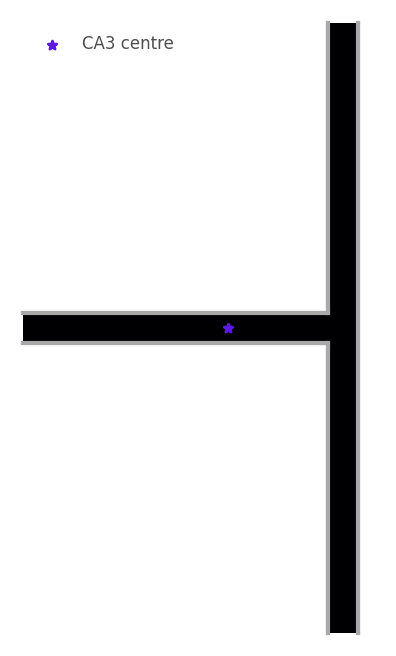

CA3 centre:        x=3.367
Mean spike x:      3.401
Median spike x:    3.418


In [270]:
# Plot spike positions directly on the maze — no binning, no transpose
fig, ax = plotter.plotMazeStructure(fig = None, ax = None)
neuron_id = 26
ep1        = results[seed]['episodes'][0] 
ep_times   = ep1['history']['t'].to_numpy(dtype=float)
ep_pos     = np.stack(ep1['history']['pos'].values).astype(float)
ep_ca1     = ep1['spikedata_by_condition']['theta']['CA1']
ep_spk_t   = np.asarray(ep_ca1['times'], dtype=float)
ep_spk_ids = np.asarray(ep_ca1['ids'], dtype=int)

mask       = (ep_spk_ids == neuron_id) & \
             (ep_spk_t >= ep_times.min()) & \
             (ep_spk_t <= ep_times.max())
ep1_spikes = ep_spk_t[mask]
spike_pos  = ep_pos[np.array([
    np.argmin(np.abs(ep_times - t)) for t in ep1_spikes # match spike times to positions within episode 1 only
])]

# raw spike dots — no heatmap, no transpose, ground truth
#ax.scatter(spike_pos[:, 0], spike_pos[:, 1],
#          c='red', s=10, alpha=0.6, zorder=3, label='CA1 spikes')
ax.scatter(*centres[neuron_id], c='#5e17eb', s=10,
           marker='*', zorder=4, label='CA3 centre')

# add heatmap of spike density for visualisation (optional)
from scipy import ndimage
from scipy.stats import gaussian_kde # kde is a non-parametric way to estimate the probability density function of a random variable, in this case the spatial density of spikes
kde = gaussian_kde(spike_pos.T) # fit kde to spike positions which means we are treating spike positions as samples from an underlying spatial distribution and want to estimate the density of that distribution across the maze. We transpose spike_pos to get shape (2, n_spikes) which is what gaussian_kde expects for 2D data.
#
# grid should should cover the entire maze area and not only spike positions. so we should consider maze boundaries, NOT spike positions
x_grid = np.linspace(0, 5.5, 110) # maze boundaries in x
y_grid = np.linspace(0, 10, 200) #maze boundaries in y 
#x_grid = np.linspace(ep_pos[:,0].min(), ep_pos[:,0].max(), 100)
#y_grid = np.linspace(ep_pos[:,1].min(), ep_pos[:,1].max(), 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

# add a filter so there is some smoothing to the heatmap, e.g. gaussian filter
#Z = ndimage.gaussian_filter(Z, sigma=3) # ndimage

# TMaze geometry
rs = agent_ST2.roomSize
hw = 0.05 * rs
arm_w = 2 * hw

inside = (
    ((X >= 0) & (X <= rs) & (Y >= rs - hw) & (Y <= rs + hw)) |
    ((X >= rs) & (X <= rs + arm_w) & (Y >= 0) & (Y <= 2 * rs))
)

# if you smooth first, re-apply the mask afterwards
masked_field = np.ma.array(Z, mask=~inside)

ax.imshow(masked_field, origin='lower', extent=[x_grid.min(), x_grid.max(), y_grid.min(), y_grid.max()], cmap='magma', alpha=1.0, zorder=2)
ax.legend(frameon=False)
#ax.set_title(f'Neuron {neuron_id} — raw spike positions ep1')
plotter.plotMazeStructure(fig=fig, ax=ax) # overlay maze structure for context
#plotter.plotGoal(fig = fig, ax=ax)
plt.show()

print(f"CA3 centre:        x={centres[neuron_id][0]:.3f}")
print(f"Mean spike x:      {spike_pos[:,0].mean():.3f}")
print(f"Median spike x:    {np.median(spike_pos[:,0]):.3f}")

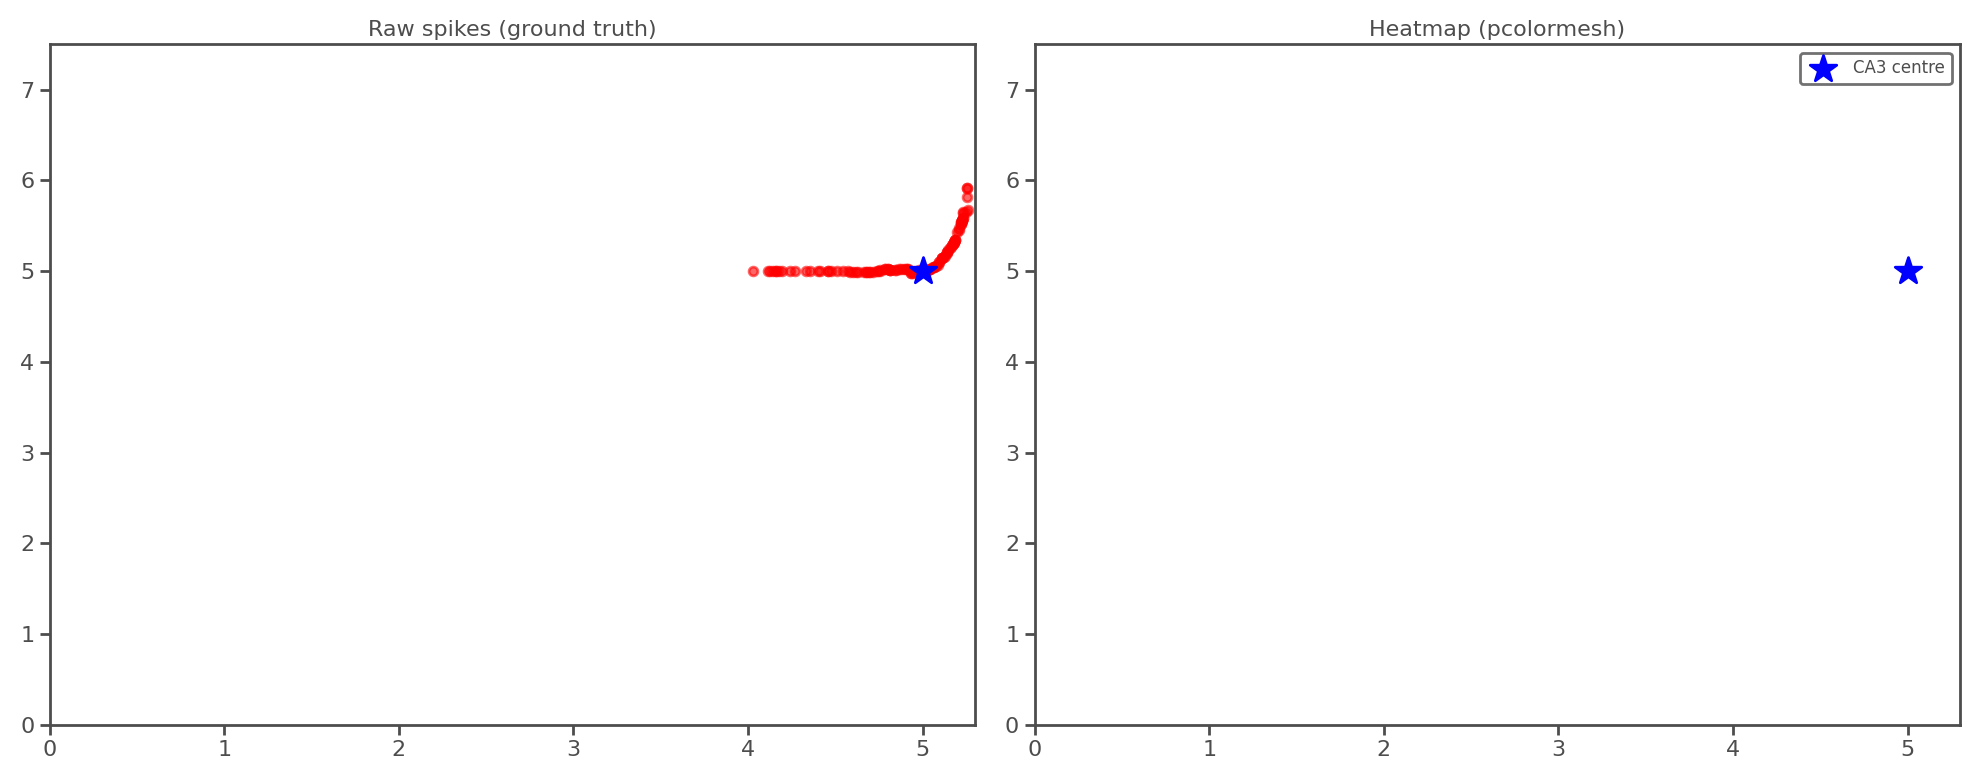

In [160]:
# Quick sanity check — does the heatmap peak match the scatter plot?
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: raw scatter (known good)
axes[0].scatter(spike_pos[:, 0], spike_pos[:, 1],
                c='red', s=10, alpha=0.6)
axes[0].scatter(*centres[neuron_id], c='blue', s=100, marker='*')
axes[0].set_title('Raw spikes (ground truth)')
axes[0].set_xlim(0, 5.3)
axes[0].set_ylim(0, 7.5)

# Right: heatmap with pcolormesh (no transpose ambiguity)
bin_size = 0.25
x_bins   = np.arange(0, 5.3 + bin_size, bin_size)
y_bins   = np.arange(0, 7.5 + bin_size, bin_size)
x_centers = (x_bins[:-1] + x_bins[1:]) / 2
y_centers = (y_bins[:-1] + y_bins[1:]) / 2

dt           = np.mean(np.diff(ep_times))
occ, _, _    = np.histogram2d(ep_pos[:,0], ep_pos[:,1], bins=[x_bins, y_bins])
occ_s        = occ * dt
spk_map, _, _ = np.histogram2d(spike_pos[:,0], spike_pos[:,1], bins=[x_bins, y_bins])

rate         = np.full(spk_map.shape, np.nan)
visited      = occ_s > 0.05
rate[visited] = spk_map[visited] / occ_s[visited]

from scipy.ndimage import gaussian_filter
smoothed     = gaussian_filter(np.nan_to_num(rate), sigma=1.5)
smoothed[~visited] = np.nan

# pcolormesh: no extent, no transpose confusion
axes[1].pcolormesh(x_centers, y_centers, smoothed.T,
                   cmap='hot', alpha=0.9)
axes[1].scatter(*centres[neuron_id], c='blue', s=100,
                marker='*', label='CA3 centre', zorder=3)
axes[1].set_title('Heatmap (pcolormesh)')
axes[1].set_xlim(0, 5.3)
axes[1].set_ylim(0, 7.5)
axes[1].legend()

plt.tight_layout()
plt.show()